# JNB3 - Build Training Set 

Welcome to this Jupyter Notebook. Here, we focus on building YAML files that encapsulate data essential for training.

This notebook corresponds to the third step in the protocol outlined in the associated article, as detailed in the README.md file. For visual reference, please see Figure 3.

**Sections Overview**

- [Jobs & Engine Collecting](#jobs_engine_collecting): In this section, we gather DFT (Density Functional Theory) simulation data and the necessary settings for optimization. We maintain consistent settings across all ReaxFF optimization steps. During each step, we run all the systems using ReaxFF and compute the objective function.

- [Data Set](#data_set): Here, we process the previously collected simulation data. We extract key quantities like energies, forces, charges, distances, etc., which are crucial for comparing ReaxFF predictions with DFT reference data. Subsequently, we divide this data into training and test sets.


<figure>
    <img src="assets/img/wf-JNB3.png" alt="JNB2 workflow">
    <figcaption><strong>Figure 3</strong>: Protocol workflow and part covered by this Jupyter Notebook highlighted in red.<figcaption>
<figure> 

## Settings

In this section, we define the constants and generators that will be used throughout the notebook:

* `MAIN_DIR_JNB3`: The main folder where the results of this Jupyter Notebook will be stored.
* `CHEM_FORMULA`: The chemical formula of the SEI component.
* `TIMEZONE`: The timezone needed to save the time of post-processing into the files
* `SEED`: Seed number for the random number generators

These constants and generators play a crucial role in ensuring reproducibility and providing the necessary inputs for various computations and simulations in this notebook.

In [ ]:
import pytz

from tools.misc import MAIN_DIR_JNB1, MAIN_DIR_JNB2, MAIN_DIR_JNB3

CHEM_FORMULA = "LiF"
TIMEZONE = pytz.timezone("Europe/Rome")
SEED = 2023

## Load libraries

In [1]:
import datetime
import glob
import os
import pickle

import matplotlib as mp
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scm.params as params
import scm.plams as scm
from prj_utils import (
    get_all_angles,
    get_all_bonds,
    get_all_dihedrals,
    get_distances_atom,
    get_surf_atoms,
    make_dir,
)
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor
from scm.plams.interfaces.molecule.ase import fromASE as ASEtoSCM
from scm.plams.interfaces.molecule.ase import toASE as SCMtoASE

matget2ase = AseAtomsAdaptor()

Making the output folder

In [ ]:
make_dir(os.path.join(MAIN_DIR_JNB3, CHEM_FORMULA))

## Jobs & Engine Collecting  <a id='jobs_engine_collecting'></a>

In [2]:
jobcollection = params.JobCollection()
enginecollection = params.EngineCollection()

### Unit cells `Geometry Optimization`

In [4]:
SIMsNAME = "0-UnitCell_GO"
TASK = "GO"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [5]:
jce_all = params.JCEntry()

In [7]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.BAND = settings.input.BAND.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"BAND_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [ ]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "0-materialproject")

systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [12]:
jobs_0 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"BAND_{SIMsNAME}"
    jobs_0[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_0)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(70) + "| Status")
print("-" * 85)
for name, simulation in jobs_0.items():
    print(f"  {name} == {simulation.name};".ljust(70) + f"| Status={simulation.check()}")

### Pure Species `Single Point`

In [14]:
SIMsNAME = "0.1-PureSpeices_SP"
TASK = "SP"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [15]:
jce_all = params.JCEntry()

In [17]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.BAND = settings.input.BAND.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"BAND_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [20]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "0.1-pure_species")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [21]:
jobs_01 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"BAND_{SIMsNAME}"
    jobs_01[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(jobcollection)

In [ ]:
print(f"Jobs added {len(jobs_01)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(70) + "| Status")
print("-" * 85)
for name, simulation in jobs_01.items():
    print(f"  {name} == {simulation.name};".ljust(70) + f"| Status={simulation.check()}")

### Supercells `Single Point`

In [24]:
SIMsNAME = "1-Supercells_SP"
TASK = "SP"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [25]:
jce_all = params.JCEntry()

In [27]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.ADF = settings.input.ADF.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"ADF_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [30]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [31]:
jobs_1 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"BAND_{SIMsNAME}"
    jobs_1[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_1)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(70) + "| Status")
print("-" * 85)
for name, simulation in jobs_1.items():
    print(f"  {name} == {simulation.name};".ljust(70) + f"| Status={simulation.check()}")

### Supercells `Geometry Optimization`

In [33]:
SIMsNAME = "1-Supercells_GO"
TASK = "GO"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [34]:
jce_all = params.JCEntry()

In [36]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.BAND = settings.input.BAND.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"BAND_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [39]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [40]:
jobs_1_GO = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"BAND_{SIMsNAME}"
    jobs_1_GO[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_1_GO)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(70) + "| Status")
print("-" * 85)
for name, simulation in jobs_1_GO.items():
    print(f"  {name} == {simulation.name};".ljust(70) + f"| Status={simulation.check()}")

### Strain `Single Poin`

In [42]:
SIMsNAME = "2-Strain_SP"
TASK = "SP"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [43]:
jce_all = params.JCEntry()

In [45]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.ADF = settings.input.ADF.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"ADF_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [48]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "2-strain")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [49]:
jobs_2 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"BAND_{SIMsNAME}"
    jobs_2[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_2)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(90) + "| Status")
print("-" * 105)
for name, simulation in jobs_2.items():
    print(f"  {name} == {simulation.name};".ljust(90) + f"| Status={simulation.check()}")

### Vacancies `Single Poin`

In [51]:
SIMsNAME = "3-Vacancies_SP"
TASK = "SP"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [52]:
jce_all = params.JCEntry()

In [54]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.ADF = settings.input.ADF.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"ADF_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [57]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "3-vacancies")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [ ]:
jobs_3 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"BAND_{SIMsNAME}"
    jobs_3[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_3)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(90) + "| Status")
print("-" * 105)
for name, simulation in jobs_3.items():
    print(f"  {name} == {simulation.name};".ljust(90) + f"| Status={simulation.check()}")

### Substitution `Single Poin`

In [60]:
SIMsNAME = "4-Substitution_SP"
TASK = "SP"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [61]:
jce_all = params.JCEntry()

In [63]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.ADF = settings.input.ADF.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"ADF_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [66]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "4-substitutions")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [67]:
jobs_4 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"BAND_{SIMsNAME}"
    jobs_4[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_4)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(90) + "| Status")
print("-" * 105)
for name, simulation in jobs_4.items():
    print(f"  {name} == {simulation.name};".ljust(90) + f"| Status={simulation.check()}")

### Interstitial `Geopmetry Optimization`

In [69]:
SIMsNAME = "5-Interstitial_GO"
TASK = "GO"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [70]:
jce_all = params.JCEntry()

In [72]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.ADF = settings.input.ADF.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"ADF_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [75]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "5.1-interstitial_PO")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [76]:
jobs_5 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"BAND_{SIMsNAME}"
    jobs_5[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_5)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(90) + "| Status")
print("-" * 105)
for name, simulation in jobs_5.items():
    print(f"  {name} == {simulation.name};".ljust(90) + f"| Status={simulation.check()}")

### Slabs `Geopmetry Optimization`

In [78]:
SIMsNAME = "6-Slabs_GO"
TASK = "GO"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [79]:
jce_all = params.JCEntry()

In [81]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.ADF = settings.input.ADF.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"ADF_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [84]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "6.1-slabs_PO")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [ ]:
jobs_6 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"BAND_{SIMsNAME}"
    jobs_6[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_6)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(90) + "| Status")
print("-" * 105)
for name, simulation in jobs_6.items():
    print(f"  {name} == {simulation.name};".ljust(90) + f"| Status={simulation.check()}")

### Amorphous `Single Point`

In [87]:
SIMsNAME = "7.1-Amorphous_SP"
TASK = "SP"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [88]:
jce_all = params.JCEntry()

In [90]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.BAND = settings.input.BAND.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"BAND_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [93]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "7.1-amorphous_frames")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [ ]:
jobs_7 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"ADF_{SIMsNAME}"
    jobs_7[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_7)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(90) + "| Status")
print("-" * 105)
for name, simulation in jobs_7.items():
    print(f"  {name} == {simulation.name};".ljust(90) + f"| Status={simulation.check()}")

### Bulk 300K `Single Point`

In [114]:
SIMsNAME = "8.1-Bulk_300K_SP"
TASK = "SP"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [115]:
jce_all = params.JCEntry()

In [117]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.BAND = settings.input.BAND.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"BAND_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [120]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "8.1-bulk_300K_frames")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [121]:
jobs_10 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"ADF_{SIMsNAME}"
    jobs_10[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_10)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(90) + "| Status")
print("-" * 105)
for name, simulation in jobs_10.items():
    print(f"  {name} == {simulation.name};".ljust(90) + f"| Status={simulation.check()}")

### Bulk 500 K `Single Point`

In [123]:
SIMsNAME = "9.1-Bulk_500K_SP"
TASK = "SP"
RUN_DIR = os.path.join(MAIN_DIR_JNB2, CHEM_FORMULA, SIMsNAME)

Settings

In [124]:
jce_all = params.JCEntry()

In [126]:
settings_pkl_file = os.path.join(RUN_DIR, "settings.pkl")
with open(settings_pkl_file, "rb") as file:
    settings = pickle.load(file)

In [ ]:
# Engine
e_all = params.Engine()
e_all.settings.input.BAND = settings.input.BAND.copy()
e_all.metadata["sim_set"] = SIMsNAME
enginecollection.add_entry(f"BAND_{SIMsNAME}", e_all)
print(e_all)

In [ ]:
# Job Settings
jce_all.settings.input.AMS = settings.input.AMS.copy()
jce_all.settings

Load *intial configuration* file

In [129]:
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "9.1-bulk_500K_frames")
systems = []

for path in np.sort(glob.glob(os.path.join(cis_dir, "*.cif"))):
    system_name = path.split(os.sep)[-1].split(".cif")[0]
    system_mat = Structure.from_file(path)
    system_ase = matget2ase.get_atoms(system_mat)
    systems.append((system_name, ASEtoSCM(system_ase)))

Load Job

In [ ]:
jobs_11 = {}
for name, system_obj in systems:
    sim_name = f"{TASK}-{name}"
    dir_jobs = os.path.abspath(os.path.join(RUN_DIR, "jobs", sim_name))
    jce = jce_all.copy()
    if not os.path.isfile(os.path.join(dir_jobs, "ams.rkf")):
        print(f"NO ams.rkf file in {dir_jobs}")
        continue
    job = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    # check
    if not job.check():
        print(f"Simulation {dir_jobs} FAILED")
        continue
    # job_path = os.path.join(ALLMAIN_DIR_JNB2, f'{sim_name}')
    jce.molecule = system_obj.copy()
    jce.metadata["sim_set"] = SIMsNAME
    jce.metadata["dir_job"] = dir_jobs
    jce.reference_engine = f"ADF_{SIMsNAME}"
    jobs_11[sim_name] = scm.AMSJob.load_external(dir_jobs, settings=jce.settings)
    jobcollection.add_entry(sim_name, jce.copy())

In [ ]:
print(f"Jobs added {len(jobs_11)}, total {len(jobcollection)}\n")
print("  (item name) == (simulation name);".ljust(90) + "| Status")
print("-" * 105)
for name, simulation in jobs_11.items():
    print(f"  {name} == {simulation.name};".ljust(90) + f"| Status={simulation.check()}")

### Storeing

save `EngineCollection`

In [132]:
now = datetime.datetime.now(TIMEZONE)
comments = dict(info=f"""Engine Collection of all jobs
@date = {now.strftime("%Y-%m-%d %H:%M:%S %Z")} ({TIMEZONE.zone})
@authors = Paolo De Angelis
@mail = paolo.deangelis@polito.it
@PLAMS = {scm.__version__}
@ParAMS = {params.__version__}""")
enginecollection.header = comments
enginecollection.store(os.path.join(MAIN_DIR_JNB3, "engine_collection.yaml"))

save `JobCollection`

In [134]:
now = datetime.datetime.now(TIMEZONE)
comments = dict(info=f"""Simulations Collection of all jobs
@date = {now.strftime("%Y-%m-%d %H:%M:%S %Z")} ({TIMEZONE.zone})
@authors = Paolo De Angelis
@mail = paolo.deangelis@polito.it
@PLAMS = {scm.__version__}
@ParAMS = {params.__version__}""")
jobcollection.header = comments
jobcollection.store(os.path.join(MAIN_DIR_JNB3, "jobs_collection.yaml"))

In [135]:
jobcollection.pickle_dump(os.path.join(MAIN_DIR_JNB3, "jobs_collection.pkl"))

/home/paolo/Desktop/Batteries/Tier0-C+EC-DMC+Li/venv_ams2022/AMS2022.1.venv/lib/python3.6/site-packages/ipykernel_launcher.py:1: DeprecationWarning:

Pickling will be removed in a future version. Please use the yaml io instead



## Data Set <a id='data_set'></a>

In [137]:
dataset = params.DataSet()
dataset_df = pd.DataFrame(columns=["chem_formula", "systems_name", "entry_type", "entry_weight", "entry_sigma"])

### Unit cells `Geometry Optimization`

In [139]:
systems_name = "Unit cells (GO)"
N_df = len(dataset_df)

##### Energy

In [140]:
entries_str = []
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "0-materialproject")
data_path = os.path.join(cis_dir, "properties.json")
# data_path = os.path.join(ALLMAIN_DIR_JNB2, f'results_0-UnitCell_SP.json')
properties_df = pd.read_json(data_path)
referece_j_name = properties_df.loc[properties_df["energy_per_atom"] == properties_df["energy_per_atom"].min()].index
data_j_names = properties_df.loc[properties_df["energy_per_atom"] != properties_df["energy_per_atom"].min()].index

referece_job_name = "GO-" + referece_j_name[0][:-4]
Natoms_ref = len(jobs_0[referece_job_name].molecule.atoms)
weight_all = []
sigma_all = []
for indx in data_j_names:
    data_job_name = "GO-" + indx[:-4]
    Natoms_data = len(jobs_0[data_job_name].molecule.atoms)
    entries_str.append(f" energy('{data_job_name}') / {Natoms_data} - energy('{referece_job_name}') / {Natoms_ref} ")
    weight_all.append(5.0 / (float(indx.split("-")[0]) + 1.0))
    sigma_all.append(1e-3)

Add entries

In [141]:
# weight = 1.0
# sigma = 1.0
# unit = ('kJ/mol', scm.Units.convert(1, 'au', 'kJ/mol'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Energy"
    dataset_df.loc[N_df, "entry_weight"] = weight
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    N_df += 1

Evaluate all the entries

In [142]:
all_jobs = {}
all_jobs.update(jobs_0)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset)

##### Charge

In [144]:
entries_str = []
weight_all = []
sigma_all = []
for name, job in jobs_0.items():
    Natoms_data = len(job.molecule.atoms)
    for ai in range(Natoms_data):
        entries_str.append(f"charges('{name}', {ai})")
        weight_all.append(2.0 / (float(name.split("-")[1]) + 1.0))
        sigma_all.append(1e-1)

Add entries

In [145]:
# weight = 0.75
# sigma = 1.0

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma)
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Charges"
    dataset_df.loc[N_df, "entry_weight"] = weight
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    N_df += 1

Evaluate all the entries

In [146]:
all_jobs = {}
all_jobs.update(jobs_0)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Lattice Parameters

In [148]:
entries_str = []
weight_all = []
sigma_all = []
for name, job in jobs_0.items():
    entries_str.append(f"lattice('{name}')")
    weight_all.append(10.0 / (float(name.split("-")[1]) + 1.0))
    sigma_all.append(1e-2)

Add entries

In [149]:
# weight = 10.0
# sigma = 1.0

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Lattice"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [150]:
all_jobs = {}
all_jobs.update(jobs_0)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Hessian

In [152]:
entries_str = []
weight_all = []
sigma_all = []

for name, job in jobs_0.items():
    entries_str.append(f"hessian('{name}')")
    weight_all.append(5.0 / (float(name.split("-")[1]) + 1.0))
    sigma_all.append(1.0)

Add entries

In [153]:
unit = ("au/Ang^2", scm.Units.convert(1, "au/Ang^2", "au/Ang^2"))


for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Hessian"
    dataset_df.loc[N_df, "entry_weight"] = weight
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    N_df += 1

Evaluate all the entries

In [154]:
all_jobs = {}
all_jobs.update(jobs_0)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Stress Tensor

In [156]:
entries_str = []
weight_all = []
sigma_all = []

for name, job in jobs_0.items():
    Natoms_data = len(job.molecule.atoms)
    entries_str.append(f"stresstensor('{name}')/{Natoms_data}")
    weight_all.append(10.0 / (float(name.split("-")[1]) + 1))
    sigma_all.append(1e-2)

Add entries

In [157]:
# weight = 1.5
# sigma = 1.0
# unit = ('kJ/mol/Ang^3', scm.Units.convert(1, 'au/Ang^3', 'kJ/mol/Ang^3'))
unit = ("au/Ang^3", scm.Units.convert(1, "au/Ang^3", "au/Ang^3"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Stress Tensor"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [158]:
all_jobs = {}
all_jobs.update(jobs_0)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Stress Tensor (relative)

In [160]:
entries_str = []
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "0-materialproject")
data_path = os.path.join(cis_dir, "properties.json")
# data_path = os.path.join(ALLMAIN_DIR_JNB2, f'results_0-UnitCell_SP.json')
properties_df = pd.read_json(data_path)
referece_j_name = properties_df.loc[properties_df["energy_per_atom"] == properties_df["energy_per_atom"].min()].index
data_j_names = properties_df.loc[properties_df["energy_per_atom"] != properties_df["energy_per_atom"].min()].index

referece_job_name = "GO-" + referece_j_name[0][:-4]
Natoms_ref = len(jobs_0[referece_job_name].molecule.atoms)
weight_all = []
sigma_all = []
for indx in data_j_names:
    data_job_name = "GO-" + indx[:-4]
    Natoms_data = len(jobs_0[data_job_name].molecule.atoms)
    entries_str.append(
        f"stresstensor('{data_job_name}') /{Natoms_data} - stresstensor('{referece_job_name}') /  {Natoms_ref} "
    )
    weight_all.append(2.5 / (float(indx.split("-")[0]) + 1))
    sigma_all.append(1e-2)

Add entries

In [161]:
# weight = 2.5
# sigma = 1.0
# # unit = ('kJ/mol/Ang^3', scm.Units.convert(1, 'au/Ang^3', 'kJ/mol/Ang^3'))
# unit = ('au/Ang^3', scm.Units.convert(1, 'au/Ang^3', 'au/Ang^3'))


# for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
#     dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
#     dataset_df.loc[N_df, 'entry_sigma'] = sigma
#     dataset_df.loc[N_df, 'chem_formula'] = CHEM_FORMULA
#     dataset_df.loc[N_df, 'systems_name'] = systems_name
#     dataset_df.loc[N_df, 'entry_type'] = 'Stress Tensor'
#     dataset_df.loc[N_df, 'entry_weight'] = weight
#     N_df += 1

Evaluate all the entries

In [162]:
all_jobs = {}
all_jobs.update(jobs_0)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Bond distance

get intila configurations for each job

In [164]:
data_mol = {}

for name, job in jobs_0.items():
    mol = job.results.get_input_molecule()
    mol = SCMtoASE(mol)
    data_mol[name] = mol.copy()

get molecule bonds

In [165]:
data_mol_bond = {}

for name, ase_mol in data_mol.items():
    data_mol_bond[name] = get_all_bonds(ase_mol, verbose=False)

In [ ]:
data_mol_bond

In [167]:
max_bond_per_type = 10

data_bond_indx = {}
for name, bond_df in data_mol_bond.items():
    data_bond_indx[name] = []
    for indx in bond_df.index:
        bonds = bond_df.loc[indx, "bonds"]
        data_bond_indx[name] += bonds

Preper Entry

In [168]:
data_j = jobs_0
entries_str = []
weight_all = []
sigma_all = []

for data_name, data_bonds in data_bond_indx.items():
    for ai, aj in data_bonds:
        entries_str.append(f"distance('{data_name}', {ai}, {aj})")
        weight_all.append(0.2 / (float(data_name.split("-")[1]) + 1.0))
        sigma_all.append(1e-2)

Add entries

In [169]:
# weight = .75
# sigma = 1.
# unit = ('Angstrom', scm.Units.convert(1, 'au', 'Angstrom'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Distance"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [170]:
all_jobs = {}
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Forces

In [172]:
entries_str = []
weight_all = []
sigma_all = []

for name, job in jobs_0.items():
    Natoms_data = len(job.molecule.atoms)
    for ai in range(Natoms_data):
        entries_str.append(f"forces('{name}', {ai})")
        weight_all.append(0.2 / (float(name.split("-")[1]) + 1))
        sigma_all.append(5e-3)

Add entries

In [173]:
# weight = .15
# sigma = 1.
# unit = ('kJ/mol/Ang', scm.Units.convert(1, 'au/Ang', 'kJ/mol/Ang'))
unit = ("au/Ang", scm.Units.convert(1, "au/Ang", "au/Ang"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Forces"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [174]:
all_jobs = {}
all_jobs.update(jobs_0)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Supercells `Single Point`

In [176]:
systems_name = "Supercells (SP)"
N_df = len(dataset_df)

##### Energy

In [177]:
referece_j = jobs_0
data_j = jobs_1
entries_str = []
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
data_path = os.path.join(cis_dir, "properties.json")
# data_path = os.path.join(ALLMAIN_DIR_JNB2, f'results_0-UnitCell_SP.json')
properties_df = pd.read_json(data_path)

weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[1])
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            scale = properties_df.loc[data_name[3:] + ".cif", "unitcell_repetition"]
            entries_str.append(f"energy('{data_name}')/{scale} - energy('{ref_name}') ")
            weight_all.append(1.0 / (float(data_name.split("-")[2]) + 1.0))
            sigma_all.append(2e-3)

Add entries

In [178]:
# weight = 1.0
# sigma = 1.0
# unit = ('kJ/mol', scm.Units.convert(1, 'au', 'kJ/mol'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Energy"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [179]:
all_jobs = {}
all_jobs.update(referece_j)
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Stress Tensor (relative)

In [181]:
referece_j = jobs_0
data_j = jobs_1
entries_str = []
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
data_path = os.path.join(cis_dir, "properties.json")
# data_path = os.path.join(ALLMAIN_DIR_JNB2, f'results_0-UnitCell_SP.json')
properties_df = pd.read_json(data_path)
weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[1])
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            scale = properties_df.loc[data_name[3:] + ".cif", "unitcell_repetition"]
            entries_str.append(f"stresstensor('{data_name}'){scale} - stresstensor('{ref_name}')")
            weight_all.append(1.0 / (float(data_name.split("-")[2]) + 1.0))
            sigma_all.append(1.0e-2)

Add entries

In [182]:
# weight = 1/1.5
# sigma = 1.0
# # unit = ('kJ/mol/Ang^3', scm.Units.convert(1, 'au/Ang^3', 'kJ/mol/Ang^3'))
# unit = ('au/Ang^3', scm.Units.convert(1, 'au/Ang^3', 'au/Ang^3'))

# for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
#     dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
#     dataset_df.loc[N_df, 'entry_sigma'] = sigma
#     dataset_df.loc[N_df, 'chem_formula'] = CHEM_FORMULA
#     dataset_df.loc[N_df, 'systems_name'] = systems_name
#     dataset_df.loc[N_df, 'entry_type'] = 'Stress Tensor'
#     dataset_df.loc[N_df, 'entry_weight'] = weight
#     N_df += 1

Evaluate all the entries

In [183]:
all_jobs = {}
all_jobs.update(jobs_0)
all_jobs.update(jobs_1)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Supercells `Geometry Optimization`

In [185]:
systems_name = "Supercells (GO)"
N_df = len(dataset_df)

##### Bond distance

get intila configurations for each job

In [186]:
referece_j = jobs_0
data_j = jobs_1_GO

data_mol = {}

for name, job in data_j.items():
    mol = job.results.get_input_molecule()
    mol = SCMtoASE(mol)
    data_mol[name] = mol.copy()

get molecule bonds

In [187]:
data_mol_bond = {}

for name, ase_mol in data_mol.items():
    data_mol_bond[name] = get_all_bonds(ase_mol, verbose=False)

In [189]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

max_bond_per_type = 10

data_bond_indx = {}
for name, bond_df in data_mol_bond.items():
    for indx in bond_df.index:
        bonds = bond_df.loc[indx, "bonds"]
        if len(bonds) > max_bond_per_type:
            rnd_indexs = np.arange(bond_df.loc[indx, "Nbonds"])
            rg.shuffle(rnd_indexs)
            rnd_indexs = rnd_indexs[:max_bond_per_type]
            data_bond_indx[name] = [bonds[bi] for bi in rnd_indexs]
        else:
            data_bond_indx[name] = bonds

Preper Entry

In [191]:
data_j = jobs_1_GO
entries_str = []
weight_all = []
sigma_all = []

for data_name, data_bonds in data_bond_indx.items():
    for ai, aj in data_bonds:
        entries_str.append(f"distance('{data_name}', {ai}, {aj})")
        weight_all.append(0.2 / (float(data_name.split("-")[2]) + 1.0))
        sigma_all.append(1e-2)

Add entries

In [192]:
# weight = .1
# sigma = 1.
# unit = ('Angstrom', scm.Units.convert(1, 'au', 'Angstrom'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Distance"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [193]:
all_jobs = {}
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Angles

get intila configurations for each job

In [195]:
referece_j = jobs_0
data_j = jobs_1_GO

data_mol = {}

for name, job in data_j.items():
    mol = job.results.get_input_molecule()
    mol = SCMtoASE(mol)
    data_mol[name] = mol.copy()

get molecule angle

In [196]:
data_mol_angle = {}

for name, ase_mol in data_mol.items():
    data_mol_angle[name] = get_all_angles(ase_mol, verbose=False)

In [198]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

max_angle_per_type = 10

data_angle_indx = {}
for name, angle_df in data_mol_angle.items():
    for indx in angle_df.index:
        angles = angle_df.loc[indx, "angles"]
        if len(angles) > max_angle_per_type:
            rnd_indexs = np.arange(angle_df.loc[indx, "Nangles"])
            rg.shuffle(rnd_indexs)
            rnd_indexs = rnd_indexs[:max_angle_per_type]
            data_angle_indx[name] = [angles[ani] for ani in rnd_indexs]
        else:
            data_angle_indx[name] = angles

Preper Entry

In [199]:
data_j = jobs_1_GO
entries_str = []
weight_all = []
sigma_all = []

for data_name, data_angles in data_angle_indx.items():
    for ai, aj, ak in data_angles:
        entries_str.append(f"angles('{data_name}', ({ai}, {aj}, {ak}) )")
        weight_all.append(1.0 / (float(data_name.split("-")[2]) + 1.0))
        sigma_all.append(3.14)

Add entries

In [200]:
for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Angles"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [201]:
all_jobs = {}
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Dihedrals

get intila configurations for each job

In [203]:
referece_j = jobs_0
data_j = jobs_1_GO

data_mol = {}

for name, job in data_j.items():
    mol = job.results.get_input_molecule()
    mol = SCMtoASE(mol)
    data_mol[name] = mol.copy()

get molecule dihedrals

In [204]:
data_mol_dihedrals = {}

for name, ase_mol in data_mol.items():
    data_mol_dihedrals[name] = get_all_dihedrals(ase_mol, verbose=False)

In [206]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

max_dihedral_per_type = 12

data_dihedral_indx = {}
for name, dihedral_df in data_mol_dihedrals.items():
    for indx in dihedral_df.index:
        dihedrals = dihedral_df.loc[indx, "dihedrals"]
        if len(dihedrals) > max_dihedral_per_type:
            rnd_indexs = np.arange(dihedral_df.loc[indx, "Ndihedrals"])
            rg.shuffle(rnd_indexs)
            rnd_indexs = rnd_indexs[:max_dihedral_per_type]
            data_dihedral_indx[name] = [dihedrals[di] for di in rnd_indexs]
        else:
            data_dihedral_indx[name] = dihedrals

Preper Entry

In [207]:
data_j = jobs_1_GO
entries_str = []
weight_all = []
sigma_all = []

for data_name, data_dihedral in data_dihedral_indx.items():
    for ai, aj, ak, al in data_dihedral:
        entries_str.append(f"dihedral('{data_name}', {ai}, {aj}, {ak}, {al} )")
        weight_all.append(1.0 / (float(data_name.split("-")[2]) + 1) ** 2)
        sigma_all.append(5e0)

Add entries

In [208]:
for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Dihedrals"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [ ]:
all_jobs = {}
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Strain `Single Point`

In [211]:
systems_name = "Strain (SP)"
N_df = len(dataset_df)

##### Energy

Get Reference

In [212]:
cis_dir_ref = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
data_pathr_ref = os.path.join(cis_dir_ref, "properties.json")
properties_ref_df = pd.read_json(data_pathr_ref)
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "2-strain")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)
supercell_size = properties_data_df["unitcell_repetition"].unique()[0]
refernce_cis = properties_ref_df.loc[properties_ref_df["unitcell_repetition"] == supercell_size].index

In [213]:
referece_j = {}
for refernce_cis_ in refernce_cis:
    ref_name = refernce_cis_[:-4]
    for name, job in jobs_1.items():
        if ref_name in name:
            referece_j[name] = job

data_j = jobs_2
entries_str = []
weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[2])
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            entries_str.append(f"energy('{data_name}') - energy('{ref_name}') ")
            weight_all.append(10000.0 / (float(data_name.split("-")[2]) + 1.0) ** 2)
            sigma_all.append(1e-3)

Add entries

In [214]:
# weight = 2.5
# sigma = 1.
# unit = ('kJ/mol', scm.Units.convert(1, 'au', 'kJ/mol'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Energy"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [215]:
all_jobs = {}
all_jobs.update(referece_j)
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Forces

Get Reference

In [217]:
cis_dir_ref = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
data_pathr_ref = os.path.join(cis_dir_ref, "properties.json")
properties_ref_df = pd.read_json(data_pathr_ref)
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "2-strain")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)
supercell_size = properties_data_df["unitcell_repetition"].unique()[0]
refernce_cis = properties_ref_df.loc[properties_ref_df["unitcell_repetition"] == supercell_size].index

In [218]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

max_forces_per_type = 8

referece_j = {}
for refernce_cis_ in refernce_cis:
    ref_name = refernce_cis_[:-4]
    for name, job in jobs_1.items():
        if ref_name in name:
            referece_j[name] = job

data_j = jobs_2
entries_str = []
weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[2])
    Natoms_data = len(ref_job.molecule.atoms)
    if Natoms_data > max_forces_per_type:
        rnd_indexs = np.arange(Natoms_data)
        rg.shuffle(rnd_indexs)
        rnd_indexs = rnd_indexs[:max_forces_per_type]
    else:
        rnd_indexs = np.arange(Natoms_data)
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            for ai in rnd_indexs:
                entries_str.append(f"forces('{data_name}', {ai}) - forces('{ref_name}', {ai})")
                weight_all.append(0.2 / (float(data_name.split("-")[2]) + 1))
                sigma_all.append(5e-3)

Add entries

In [219]:
# weight = .25
# sigma = 1.
# unit = ('kJ/mol/Ang', scm.Units.convert(1, 'au/Ang', 'kJ/mol/Ang'))
unit = ("au/Ang", scm.Units.convert(1, "au/Ang", "au/Ang"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Forces"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [220]:
all_jobs = {}
all_jobs.update(referece_j)
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Vacancies `Single Poin`

In [222]:
systems_name = "Vacancies (SP)"
N_df = len(dataset_df)

##### Energy

Get Reference

In [223]:
cis_dir_ref = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
data_pathr_ref = os.path.join(cis_dir_ref, "properties.json")
properties_ref_df = pd.read_json(data_pathr_ref)
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "3-vacancy")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "0.1-pure_species")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_elem_df = pd.read_json(data_path_data)
supercell_size = properties_data_df["unitcell_repetition"].unique()[0]
refernce_cis = properties_ref_df.loc[properties_ref_df["unitcell_repetition"] == supercell_size].index

In [224]:
referece_j = {}
for refernce_cis_ in refernce_cis:
    ref_name = refernce_cis_[:-4]
    for name, job in jobs_1.items():
        if ref_name in name:
            referece_j[name] = job

data_j = jobs_3
elemets_j = jobs_01
entries_str = []
weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[2])
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            vacancy_atoms_str = ""
            for sim_name, el in zip(elemets_j.keys(), properties_elem_df["element"]):
                N_v = properties_data_df.loc[data_name[3:] + ".cif", "vacancy_element"].count(el)
                N_el = properties_elem_df.loc[sim_name[3:] + ".cif", "N"]
                vacancy_atoms_str += f" +energy('{sim_name}')*{N_v}/{N_el}"
            entries_str.append(f"energy('{data_name}') {vacancy_atoms_str} -energy('{ref_name}')")
            weight_all.append(1.0 / (float(data_name.split("-")[2]) + 1.0))
            sigma_all.append(2e-3)

Add entries

In [225]:
# weight = 1.
# sigma = 1.
# unit = ('kJ/mol', scm.Units.convert(1, 'au', 'kJ/mol'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Energy"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [226]:
all_jobs = {}
all_jobs.update(referece_j)
all_jobs.update(data_j)
all_jobs.update(elemets_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Charge

Get metadata

In [228]:
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "3-vacancy")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)

get systems molecules

In [229]:
data_j = jobs_3

data_mol = {}

for name, job in data_j.items():
    mol = job.results.get_input_molecule()
    mol = SCMtoASE(mol)
    data_mol[name] = mol.copy()

get vacancies neighbors

In [230]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

cut_off = 2.5  # [Ang]
data_vacacies_neighbors = {}
max_vacacies_per_type = 5

for index_v in properties_data_df.index:
    sim_name = "SP-" + index_v[:-4]
    data_vacacies_neighbors[sim_name] = []
    for vacancies_r in properties_data_df.loc[index_v, "vacancy_site"]:
        dist = get_distances_atom(data_mol[sim_name], vacancies_r, mic=True)
        indx = np.where(dist <= cut_off)[0].tolist()
        data_vacacies_neighbors[sim_name] += indx
    data_vacacies_neighbors[sim_name] = np.unique(data_vacacies_neighbors[sim_name])
    rg.shuffle(data_vacacies_neighbors[sim_name])

Preper Entry

In [231]:
entries_str = []
weight_all = []
sigma_all = []

for data_name, data_job in data_j.items():
    neighbors = data_vacacies_neighbors[data_name]
    if len(neighbors) > max_vacacies_per_type:
        neighbors = neighbors[:max_vacacies_per_type]
    for ai in neighbors:
        entries_str.append(f"charges('{data_name}', {ai})")
        weight_all.append(0.2 / (float(data_name.split("-")[2]) + 1.0))
        sigma_all.append(1e-1)

Add entries

In [232]:
# weight = .1
# sigma = 1.

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Charges"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [233]:
all_jobs = {}
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Substitution `Single Poin`

In [235]:
systems_name = "Substitution (SP)"
N_df = len(dataset_df)

##### Energy

Get Reference

In [236]:
cis_dir_ref = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
data_pathr_ref = os.path.join(cis_dir_ref, "properties.json")
properties_ref_df = pd.read_json(data_pathr_ref)
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "4-substitution")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)
supercell_size = properties_data_df["unitcell_repetition"].unique()[0]
refernce_cis = properties_ref_df.loc[properties_ref_df["unitcell_repetition"] == supercell_size].index

In [237]:
referece_j = {}
for refernce_cis_ in refernce_cis:
    ref_name = refernce_cis_[:-4]
    for name, job in jobs_1.items():
        if ref_name in name:
            referece_j[name] = job

data_j = jobs_4
entries_str = []
weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[2])
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            entries_str.append(f"energy('{data_name}') - energy('{ref_name}')")
            weight_all.append(5e-2 / (float(data_name.split("-")[2]) + 1.0))
            sigma_all.append(2e-3)

Add entries

In [238]:
# weight = 1.
# sigma = 1.
# unit = ('kJ/mol', scm.Units.convert(1, 'au', 'kJ/mol'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Energy"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [239]:
all_jobs = {}
all_jobs.update(referece_j)
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Forces

Get metadata

In [241]:
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "4-substitution")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)

get systems molecules

In [243]:
data_j = jobs_4

data_mol = {}

for name, job in data_j.items():
    mol = job.results.get_input_molecule()
    mol = SCMtoASE(mol)
    data_mol[name] = mol.copy()

get vacancies neighbors

In [244]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

cut_off = 2.5  # [Ang]
data_substitution_neighbors = {}
max_substitution_per_type = 5

for index_v in properties_data_df.index:
    sim_name = "SP-" + index_v[:-4]
    data_substitution_neighbors[sim_name] = []
    for vacancies_r in properties_data_df.loc[index_v, "substitution_site"]:
        dist = get_distances_atom(data_mol[sim_name], vacancies_r, mic=True)
        indx = np.where(dist <= cut_off)[0].tolist()
        data_substitution_neighbors[sim_name] += indx
    data_substitution_neighbors[sim_name] = np.unique(data_substitution_neighbors[sim_name])
    rg.shuffle(data_substitution_neighbors[sim_name])

Preper Entry

In [245]:
entries_str = []
weight_all = []
sigma_all = []

for data_name, data_job in data_j.items():
    neighbors = data_substitution_neighbors[data_name]
    if len(neighbors) > max_substitution_per_type:
        neighbors = neighbors[:max_substitution_per_type]
    for ai in neighbors:
        entries_str.append(f"forces('{data_name}', {ai})")
        weight_all.append(5e-2 / (float(data_name.split("-")[2]) + 1.0))
        sigma_all.append(5e-3)

Add entries

In [246]:
# weight = .15
# sigma = 1.
unit = ("au/Ang", scm.Units.convert(1, "au/Ang", "au/Ang"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Forces"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [247]:
all_jobs = {}
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Interstitial `Geometry Optimization`

In [249]:
systems_name = "Interstitial (GO)"
N_df = len(dataset_df)

##### Energy

Get Reference

In [250]:
cis_dir_ref = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
data_pathr_ref = os.path.join(cis_dir_ref, "properties.json")
properties_ref_df = pd.read_json(data_pathr_ref)
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "5-interstitial")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "0.1-pure_species")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_elem_df = pd.read_json(data_path_data)
supercell_size = properties_data_df["unitcell_repetition"].unique()[0]
refernce_cis = properties_ref_df.loc[properties_ref_df["unitcell_repetition"] == supercell_size].index

In [252]:
referece_j = {}
for refernce_cis_ in refernce_cis:
    ref_name = refernce_cis_[:-4]
    for name, job in jobs_1.items():
        if ref_name in name:
            referece_j[name] = job

data_j = jobs_5
elemets_j = jobs_01
entries_str = []
weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[2])
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            vacancy_atoms_str = ""
            for sim_name, el in zip(elemets_j.keys(), properties_elem_df["element"]):
                N_v = properties_data_df.loc[data_name[3:] + ".cif", "interstitial_element"].count(el)
                N_el = properties_elem_df.loc[sim_name[3:] + ".cif", "N"]
                vacancy_atoms_str += f" -energy('{sim_name}')*{N_v}/{N_el}"
            entries_str.append(f"energy('{data_name}') {vacancy_atoms_str} -energy('{ref_name}')")
            weight_all.append(1.0 / (float(data_name.split("-")[2]) + 1.0))
            sigma_all.append(2e-3)

Add entries

In [253]:
# weight = 1.
# sigma = 1.
# unit = ('kJ/mol', scm.Units.convert(1, 'au', 'kJ/mol'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Energy"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [254]:
all_jobs = {}
all_jobs.update(data_j)
all_jobs.update(referece_j)
all_jobs.update(elemets_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Forces

Get metadata

In [256]:
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "5.1-interstitial_PO")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)

get systems molecules

In [258]:
data_j = jobs_5

data_mol = {}

for name, job in data_j.items():
    mol = job.results.get_input_molecule()
    mol = SCMtoASE(mol)
    data_mol[name] = mol.copy()

get vacancies neighbors

In [259]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

cut_off = 2.5  # [Ang]
data_interstitial_neighbors = {}
max_interstitial_per_type = 5

for index_v in properties_data_df.index:
    sim_name = "GO-" + index_v[:-4]
    data_interstitial_neighbors[sim_name] = []
    for interstitial_r in properties_data_df.loc[index_v, "interstitial_site"]:
        dist = get_distances_atom(data_mol[sim_name], interstitial_r, mic=True)
        indx = np.where(dist <= cut_off)[0].tolist()
        data_interstitial_neighbors[sim_name] += indx
    data_interstitial_neighbors[sim_name] = np.unique(data_interstitial_neighbors[sim_name])
    rg.shuffle(data_interstitial_neighbors[sim_name])

Preper Entry

In [260]:
entries_str = []
weight_all = []
sigma_all = []
f_prj = 0  # x component

for data_name, data_job in data_j.items():
    N_atoms = len(data_mol[data_name])
    for ai in range(N_atoms):
        entries_str.append(f"forces('{data_name}', {ai}, {f_prj})")
        weight_all.append(0.8)
        sigma_all.append(5e-3)

Add entries

In [261]:
# weight = .15
# sigma = 1.
unit = ("au/Ang", scm.Units.convert(1, "au/Ang", "au/Ang"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Forces"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [262]:
all_jobs = {}
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Charge

Get metadata

In [264]:
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "5.1-interstitial_PO")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)

In [265]:
# properties_data_df

get systems molecules

In [266]:
data_j = jobs_5

data_mol = {}

for name, job in data_j.items():
    mol = job.results.get_input_molecule()
    mol = SCMtoASE(mol)
    data_mol[name] = mol.copy()

get vacancies neighbors

In [267]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

cut_off = 2.5  # [Ang]
data_interstitial_atoms = {}
max_interstitial_per_type = 5

for index_v in properties_data_df.index:
    sim_name = "GO-" + index_v[:-4]
    data_interstitial_neighbors[sim_name] = []
    Natoms = len(data_mol[sim_name])
    Nint = len(properties_data_df.loc[index_v, "interstitial_site"])
    data_interstitial_atoms[sim_name] = np.arange(Natoms - Nint, Natoms)

Preper Entry

In [268]:
entries_str = []
weight_all = []
sigma_all = []

for data_name, data_job in data_j.items():
    interstitials = data_interstitial_atoms[data_name]
    for ai in interstitials:
        entries_str.append(f"charges('{data_name}', {ai})")
        weight_all.append(0.2 / (float(data_name.split("-")[2]) + 1.0))
        sigma_all.append(1e-1)

Add entries

In [269]:
# weight = .1
# sigma = 1.

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Charges"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [270]:
all_jobs = {}
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Slabs `Geometry Optimization`

In [272]:
systems_name = "Slabs (GO)"
N_df = len(dataset_df)

##### Energy

Get Reference

In [273]:
referece_j = jobs_0
data_j = jobs_6
entries_str = []
cis_dir = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "6.1-slabs_PO")
data_path = os.path.join(cis_dir, "properties.json")
properties_df = pd.read_json(data_path)
weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[1])
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            Na_ref = len(ref_job.results.get_input_molecule())
            Na_data = len(data_job.results.get_input_molecule())
            entries_str.append(f"energy('{data_name}')/{Na_data} - energy('{ref_name}')/{Na_ref} ")
            weight_all.append(1.0 / (float(data_name.split("-")[2]) + 1.0))
            sigma_all.append(2e-3)

Add entries

In [274]:
# weight = 1.
# sigma = 1.
# unit = ('kJ/mol', scm.Units.convert(1, 'au', 'kJ/mol'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Energy"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [275]:
all_jobs = {}
all_jobs.update(referece_j)
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Bond distance

get intila configurations for each job

In [277]:
data_mol = {}

for name, job in jobs_6.items():
    mol = job.results.get_input_molecule()
    mol = SCMtoASE(mol)
    data_mol[name] = mol.copy()

get molecule bonds

In [278]:
data_mol_bond = {}

for name, ase_mol in data_mol.items():
    data_mol_bond[name] = get_all_bonds(ase_mol, verbose=False)

In [ ]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

max_bond_per_type = 10

data_bond_indx = {}
for name, ase_mol in data_mol.items():
    surf_atoms = get_surf_atoms(ase_mol, cutoff=3.0, coord_cutoff=0.5)
    bond_df = data_mol_bond[name]
    for indx in bond_df.index:
        bonds_all = bond_df.loc[indx, "bonds"]
        # get only bond with surface atoms
        bonds = []
        for ai, aj in bonds_all:
            if (ai in surf_atoms) or (aj in surf_atoms):
                bonds.append((ai, aj))
        if len(bonds) > max_bond_per_type:
            rnd_indexs = np.arange(len(bonds))
            rg.shuffle(rnd_indexs)
            rnd_indexs = rnd_indexs[:max_bond_per_type]
            data_bond_indx[name] = [bonds[bi] for bi in rnd_indexs]
        else:
            data_bond_indx[name] = bonds

Preper Entry

In [281]:
data_j = jobs_6
entries_str = []
weight_all = []
sigma_all = []


for data_name, data_bonds in data_bond_indx.items():
    for ai, aj in data_bonds:
        entries_str.append(f"distance('{data_name}', {ai}, {aj})")
        weight_all.append(0.2 / (float(data_name.split("-")[2]) + 1.0))
        sigma_all.append(1e-2)

Add entries

In [282]:
# weight = .1
# sigma = 1.
# unit = ('Angstrom', scm.Units.convert(1, 'au', 'Angstrom'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Distance"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [283]:
all_jobs = {}
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

##### Angles

get intila configurations for each job

In [285]:
data_mol = {}

for name, job in jobs_6.items():
    mol = job.results.get_input_molecule()
    mol = SCMtoASE(mol)
    data_mol[name] = mol.copy()

get molecule angles

In [286]:
data_mol_angle = {}

for name, ase_mol in data_mol.items():
    data_mol_angle[name] = get_all_angles(ase_mol, verbose=False)

In [287]:
# data_mol_angle

In [288]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

max_angle_per_type = 10

data_angle_indx = {}
for name, ase_mol in data_mol.items():
    surf_atoms = get_surf_atoms(ase_mol, cutoff=3.0, coord_cutoff=0.5)
    angle_df = data_mol_angle[name]
    for indx in angle_df.index:
        angles_all = angle_df.loc[indx, "angles"]
        # get only angle with surface atoms
        angles = []
        for ai, aj, ak in angles_all:
            if (ai in surf_atoms) or (aj in surf_atoms) or (ak in surf_atoms):
                angles.append((ai, aj, ak))
        if len(angles) > max_angle_per_type:
            rnd_indexs = np.arange(len(angles))
            rg.shuffle(rnd_indexs)
            rnd_indexs = rnd_indexs[:max_angle_per_type]
            data_angle_indx[name] = [angles[bi] for bi in rnd_indexs]
        else:
            data_angle_indx[name] = angles

Preper Entry

In [289]:
data_j = jobs_6
entries_str = []
weight_all = []
sigma_all = []

for data_name, data_angles in data_angle_indx.items():
    for ai, aj, ak in data_angles:
        entries_str.append(f"angles('{data_name}', ({ai}, {aj}, {ak}) )")
        weight_all.append(1.0 / (float(data_name.split("-")[2]) + 1))
        sigma_all.append(3.14)

Add entries

In [290]:
# weight = .35
# sigma = 1.
# unit = ('Angstrom', scm.Units.convert(1, 'au', 'Angstrom'))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Angles"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [291]:
all_jobs = {}
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Amorphous bulk `Single Point`

In [293]:
systems_name = "Amorphous bulk  (SP)"
N_df = len(dataset_df)

##### Energy

Get Reference

In [294]:
cis_dir_ref = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
data_pathr_ref = os.path.join(cis_dir_ref, "properties.json")
properties_ref_df = pd.read_json(data_pathr_ref)
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "7.1-amorphous_frames")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)
supercell_size = properties_data_df["unitcell_repetition"].unique()[0]
refernce_cis = properties_ref_df.loc[properties_ref_df["unitcell_repetition"] == supercell_size].index

In [295]:
referece_j = {}
for refernce_cis_ in refernce_cis:
    ref_name = refernce_cis_[:-4]
    for name, job in jobs_1.items():
        if ref_name in name:
            referece_j[name] = job

data_j = jobs_7
entries_str = []
weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[2])
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            entries_str.append(f"energy('{data_name}') - energy('{ref_name}') ")
            weight_all.append(1.0 / (float(data_name.split("-")[2]) + 1.0))
            sigma_all.append(2e-3)

Add entries

In [296]:
# weight = 1.
# sigma = 1.
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Energy"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [297]:
all_jobs = {}
all_jobs.update(referece_j)
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Bulk 300 K `Single Point`

In [319]:
systems_name = "Bulk at 300 K (SP)"
N_df = len(dataset_df)

##### Energy

Get Reference

In [320]:
cis_dir_ref = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
data_pathr_ref = os.path.join(cis_dir_ref, "properties.json")
properties_ref_df = pd.read_json(data_pathr_ref)
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "10.1-bulk_300K_frames")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)
supercell_size = properties_data_df["unitcell_repetition"].unique()[0]
refernce_cis = properties_ref_df.loc[properties_ref_df["unitcell_repetition"] == supercell_size].index

In [321]:
referece_j = {}
for refernce_cis_ in refernce_cis:
    ref_name = refernce_cis_[:-4]
    for name, job in jobs_1.items():
        if ref_name in name:
            referece_j[name] = job

data_j = jobs_10
entries_str = []
weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[2])
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            entries_str.append(f"energy('{data_name}') - energy('{ref_name}') ")
            weight_all.append(10.0 / (float(data_name.split("-")[2]) + 1.0))
            sigma_all.append(2e-3)

Add entries

In [322]:
# weight = 1.
# sigma = 1.
# unit = ('kJ/mol', scm.Units.convert(1, 'au', 'kJ/mol'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Energy"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [323]:
all_jobs = {}
all_jobs.update(referece_j)
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Bulk 500 K `Single Point`

In [325]:
systems_name = "Bulk at 500 K (SP)"
N_df = len(dataset_df)

##### Energy

Get Reference

In [326]:
cis_dir_ref = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "1-supercell")
data_pathr_ref = os.path.join(cis_dir_ref, "properties.json")
properties_ref_df = pd.read_json(data_pathr_ref)
cis_dir_data = os.path.join(MAIN_DIR_JNB1, CHEM_FORMULA, "11.1-bulk_500K_frames")
data_path_data = os.path.join(cis_dir_data, "properties.json")
properties_data_df = pd.read_json(data_path_data)
supercell_size = properties_data_df["unitcell_repetition"].unique()[0]
refernce_cis = properties_ref_df.loc[properties_ref_df["unitcell_repetition"] == supercell_size].index

In [327]:
referece_j = {}
for refernce_cis_ in refernce_cis:
    ref_name = refernce_cis_[:-4]
    for name, job in jobs_1.items():
        if ref_name in name:
            referece_j[name] = job

data_j = jobs_11
entries_str = []
weight_all = []
sigma_all = []

for ref_name, ref_job in referece_j.items():
    ref_ID = int(ref_name.split("-")[2])
    for data_name, data_job in data_j.items():
        data_ID = int(data_name.split("-")[2])
        if ref_ID == data_ID:
            entries_str.append(f"energy('{data_name}') - energy('{ref_name}') ")
            weight_all.append(10.0 / (float(data_name.split("-")[2]) + 1.0))
            sigma_all.append(2e-3)

Add entries

In [328]:
# weight = 1.
# sigma = 1.
# unit = ('kJ/mol', scm.Units.convert(1, 'au', 'kJ/mol'))
unit = ("au", scm.Units.convert(1, "au", "au"))

for entry, weight, sigma in zip(entries_str, weight_all, sigma_all):
    dataset.add_entry(entry, weight, sigma=sigma, unit=unit)
    dataset_df.loc[N_df, "entry_sigma"] = sigma
    dataset_df.loc[N_df, "chem_formula"] = CHEM_FORMULA
    dataset_df.loc[N_df, "systems_name"] = systems_name
    dataset_df.loc[N_df, "entry_type"] = "Energy"
    dataset_df.loc[N_df, "entry_weight"] = weight
    N_df += 1

Evaluate all the entries

In [329]:
all_jobs = {}
all_jobs.update(referece_j)
all_jobs.update(data_j)
all_results = {}

for name, job in all_jobs.items():
    all_results[name] = job.results

dataset.calculate_reference(all_results)

Show last 5

In [ ]:
print(dataset[-5:])

### Storeing

check CONSISTENCY

In [333]:
bad_ids = dataset.check_consistency(jobcollection)
if len(bad_ids) > 0:
    raise RuntimeError(f"The Dataset entries {len(bad_ids)} are INCONSISTENT with the JobCollection")
else:
    print("ALL GOOD")

ALL GOOD


### Saving `DataSet`

In [ ]:
# Remove problematic
job_ids = set(dataset.jobids)
print(len(job_ids))
for job_name in dataset.jobids:
    if "-0.200" in job_name:
        print(f"{job_name} removed")
        job_ids.remove(job_name)

print(len(job_ids))
dataset = dataset.from_jobids(job_ids)

In [336]:
now = datetime.datetime.now(TIMEZONE)
comments = dict(info=f"""Full Datasets entries
@date = {now.strftime("%Y-%m-%d %H:%M:%S %Z")} ({TIMEZONE.zone})
@authors = Paolo De Angelis
@mail = paolo.deangelis@polito.it
@PLAMS = {scm.__version__}
@ParAMS = {params.__version__}""")
dataset.header = comments
dataset.store(os.path.join(MAIN_DIR_JNB3, "dataset.yaml"))

split in `dataset`

In [337]:
from numpy.random import PCG64, Generator

pcg64 = PCG64(seed=SEED)
rg = Generator(pcg64)

job_ids = set()
# crystal
job_ids = job_ids.union(set(jobs_0.keys()))
# supercell
# drop last system
jobs_sc = []
for job_name in jobs_1.keys():
    if "2-LiF_Pm-3m" not in job_name:
        jobs_sc.append(job_name)
job_ids = job_ids.union(set(jobs_sc))
# strain
jobs_strain = []
for job_name in jobs_2.keys():
    if "2-LiF_Pm-3m" not in job_name:
        jobs_strain.append(job_name)
N = len(jobs_strain)
rg.shuffle(jobs_strain)
job_ids = job_ids.union(set(jobs_strain[: int(N * 0.7)]))
# 300 K
job_ids = job_ids.union(set(jobs_10.keys()))
# 500 K
job_ids = job_ids.union(set(jobs_11.keys()))

In [ ]:
job_ids = set(dataset.jobids)
print(len(job_ids))
for job_name in dataset.jobids:
    if "LiF_Pm-3m" in job_name:
        job_ids.remove(job_name)

print(len(job_ids))
dataset_2over3 = dataset.from_jobids(job_ids)

job_ids = set(dataset.jobids)
print(len(job_ids))
for job_name in dataset.jobids:
    if "LiF_Pm-3m" in job_name or "LiF_P6_3mc" in job_name:
        job_ids.remove(job_name)

print(len(job_ids))
dataset_1over3 = dataset.from_jobids(job_ids)

Training Set

In [342]:
now = datetime.datetime.now(TIMEZONE)
comments = dict(info=f"""Train Set entries
@date = {now.strftime("%Y-%m-%d %H:%M:%S %Z")} ({TIMEZONE.zone})
@authors = Paolo De Angelis
@mail = paolo.deangelis@polito.it
@PLAMS = {scm.__version__}
@ParAMS = {params.__version__}""")
dataset_1over3.header = comments
dataset_1over3.store(os.path.join(MAIN_DIR_JNB3, "training_set.yaml"))

1/3 set = 1153 with 184 jobs


Test Set

In [ ]:
now = datetime.datetime.now(TIMEZONE)
comments = dict(info=f"""Train Set entries
@date = {now.strftime("%Y-%m-%d %H:%M:%S %Z")} ({TIMEZONE.zone})
@authors = Paolo De Angelis
@mail = paolo.deangelis@polito.it
@PLAMS = {scm.__version__}
@ParAMS = {params.__version__}""")
dataset_2over3.header = comments
dataset_2over3.store(os.path.join(MAIN_DIR_JNB3, "test_set.yaml"))

Save dataset metadata

In [346]:
dataset_df.to_json(os.path.join(MAIN_DIR_JNB3, "dataset_metadata.json"))

## Plot Dataset

### Entries

In [ ]:
dataset_df = pd.read_json(os.path.join(MAIN_DIR_JNB3, "dataset_metadata.json"))
dataset_df

In [348]:
cmap = mp.cm.get_cmap("bone")
inner_color = cmap(np.arange(14) / 14)
cmap = mp.cm.get_cmap("tab10")
outer_color = cmap(np.arange(14))

entry_type_label = []
entry_type_count = []
entry_type_colors = []
system_label = []
system_count = []
system_colors = []
system_names = dataset_df["systems_name"].unique()

for i, entry_type in enumerate(dataset_df["entry_type"].unique()):
    sub_df = dataset_df.loc[dataset_df["entry_type"] == entry_type]
    entry_type_label.append(entry_type)
    entry_type_count.append(len(sub_df))
    entry_type_colors.append(outer_color[i].tolist())
    for j, systems_name in enumerate(sub_df["systems_name"].unique()):
        sub_sub_df = sub_df.loc[sub_df["systems_name"] == systems_name]
        system_label.append(systems_name)
        system_count.append(len(sub_sub_df))
        nc = np.where(system_names == systems_name)[0][0]
        system_colors.append(inner_color[nc].tolist())

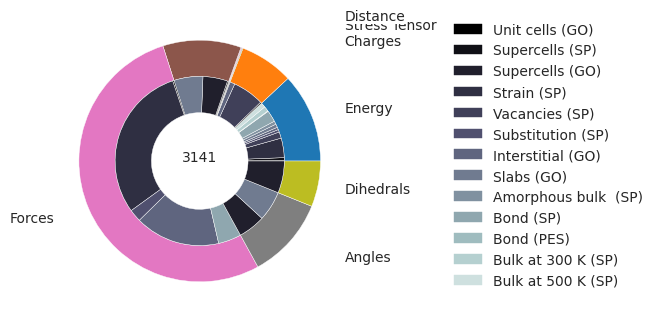

In [349]:
fig = plt.figure(figsize=[7, 4], dpi=100, facecolor="white")

bbox_props = dict(boxstyle="square,pad=0.1", fc="w", ec="none", lw=0.72)
kw = dict(arrowprops=dict(arrowstyle="-"), bbox=bbox_props, zorder=0, va="center")

with plt.style.context("seaborn"):
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax = fig.add_subplot(spec[0])
    wedges, texts = ax.pie(
        entry_type_count,
        radius=1,  # labels=entry_type_label,
        colors=entry_type_colors,
        wedgeprops=dict(width=0.3, edgecolor="white"),
    )
    ax.pie(system_count, radius=0.7, colors=system_colors, wedgeprops=dict(width=0.3, edgecolor="white"))
    ax.annotate(f"{len(dataset_df)}", xy=(0.0, 0.0), xytext=(0.0, 0.0), horizontalalignment="center")
    # labels
    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1) / 2.0 + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        ax.annotate(
            entry_type_label[i],
            xy=(x, y),
            xytext=(1.2 * np.sign(x), 1.2 * y),
            horizontalalignment=horizontalalignment,
            **kw,
        )
    inner_patch = []
    for i, label in enumerate(dataset_df["systems_name"].unique()):
        inner_patch.append(mp.patches.Patch(color=inner_color[i], label=label))
    ax.legend(handles=inner_patch, loc="upper left", bbox_to_anchor=(1.3, 1.0))
fig.savefig(os.path.join("plots", "dataset_entries.png"), dpi=330, bbox_inches="tight", facecolor="none")
fig.savefig(os.path.join("plots", "dataset_entries.pdf"), dpi=330, bbox_inches="tight", facecolor="none")